# Experiment 1: agreement counts and Qwen candidate logits

This notebook constructs `num_question_sets * 2**K` exhaustive noisy-channel transcripts **per model**. It uses the actual tokenizer loaded from each configured Qwen3.5 model ID; there are no dummy tokenizer or model objects. For each transcript, it records per-question agreement with candidates $X$ and $Y$, total agreement, and the raw vocabulary logits for the one-token candidate surfaces at the first answer position.

`MetricSpec` identifies the candidate suffix surfaces (`2` and `7`) and their token IDs. The runner opens an assistant response with the prefill `ANSWER:`; `CaptureSpec(logits_boundaries=("answer",))` therefore captures the full raw-logit vector at the literal colon token, immediately before the model must emit `2` or `7`. Zero-budget completions are accepted only when the complete response is a bare allowed value or an exact `ANSWER:` response with no explanation.

In [1]:
from __future__ import annotations

import logging
import os

os.environ.setdefault("TORCHAO_FORCE_SKIP_LOADING_SO_FILES", "1")
logging.getLogger("torchao").setLevel(logging.ERROR)

import csv
import gc
import hashlib
import html
import math
import re
import sys
from collections import defaultdict
from fractions import Fraction
from pathlib import Path
from statistics import fmean

import matplotlib.pyplot as plt
import torch
from IPython.display import HTML, display
from transformers import AutoProcessor

REPO_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

# All experiment-framework imports come from noisy_channel_bayesian.
from mats_experiments.noisy_channel_bayesian import (
    CaptureSpec,
    ExecutionConfig,
    MetricSpec,
    ModelConfig,
    NoisyChannelBayesianEnvironment,
    QwenRunner,
    RandomSubsetQuestion,
    SystemPrompt,
    TokenizerBinding,
    TranscriptDataset,
    TranscriptDatasetGenerator,
    XVsYPosteriorProbe,
    answer_patterns,
    get_answer_surface_logits,
)

## Configuration

`MODEL_SELECTION` accepts either one model ID string or a list of model ID strings. Every model gets a separately tokenized dataset and a separate run directory, while the fixed seed keeps its sampled question banks identical across models.

In [10]:
# Requested experiment constants.
N = 8
K = 3
R_VALUES = "9/10"
SYSTEM_PROMPT_TEXT = (
    "You are a bayesian reasoner. Follow the user's game rules exactly."
)
NUM_QUESTION_SETS = 30

# Use a string for one model, or e.g. ["Qwen/Qwen3.5-4B", "Qwen/Qwen3.5-9B"].
MODEL_SELECTION: str | list[str] = "Qwen/Qwen3.5-4B"

# The requested fixed probe and question construction.
X = 2
Y = 7
SUBSET_SIZE = 4
SEED = 20260902

# Execution settings.
MODEL_DTYPE = "auto"
DEVICE_MAP = None  # None lets QwenRunner choose "auto" when CUDA is available.
BATCH_SIZE = 2
MAX_ANSWER_TOKENS = 4
LOCAL_FILES_ONLY = False
RUN_MODEL = True
EXPERIMENT_ROOT = REPO_ROOT / "artifacts" / "noisy_channel_bayesian_experiment_1"

In [11]:
def normalize_model_ids(selection: str | list[str]) -> list[str]:
    if isinstance(selection, str):
        model_ids = [selection]
    elif isinstance(selection, list) and all(isinstance(item, str) for item in selection):
        model_ids = list(selection)
    else:
        raise TypeError("MODEL_SELECTION must be a model ID string or a list of strings.")
    if not model_ids or any(not item.strip() for item in model_ids):
        raise ValueError("At least one non-empty model ID is required.")
    if len(set(model_ids)) != len(model_ids):
        raise ValueError("MODEL_SELECTION contains a duplicate model ID.")
    return model_ids


def model_key(model_id: str) -> str:
    readable = re.sub(r"[^A-Za-z0-9_.-]+", "_", model_id).strip("_")
    digest = hashlib.sha256(model_id.encode()).hexdigest()[:8]
    return f"{readable}_{digest}"


MODEL_IDS = normalize_model_ids(MODEL_SELECTION)
environment = NoisyChannelBayesianEnvironment(n=N, k=K, r_values=R_VALUES)
question = RandomSubsetQuestion(subset_size=SUBSET_SIZE, replacement=False, sort=True)
probe = XVsYPosteriorProbe(
    x=X,
    y=Y,
    reasoning_budget=0,
    allow_same=False,
    call_layout="conversation",
)
system_prompt = SystemPrompt(SYSTEM_PROMPT_TEXT)

# MetricSpec maps X/Y to their model-facing token surfaces. CaptureSpec stores raw logits.
# Sequence scoring is disabled because the requested quantities are raw logits, not log-probs.
metric_spec = MetricSpec(sequence_scores=False)
capture_spec = CaptureSpec(
    logits_boundaries=("answer",),
    streams=(),
    every_decode_position=False,
)

assert environment.shared_reliability
assert len(set(environment.reliabilities)) == 1
assert 0 < environment.reliabilities[0] < 1
assert probe == XVsYPosteriorProbe(
    x=2, y=7, reasoning_budget=0, allow_same=False, call_layout="conversation"
)
print({
    "models": MODEL_IDS,
    "rows_per_model": NUM_QUESTION_SETS * 2**K,
    "reliability": str(environment.reliabilities[0]),
    "artifact_root": str(EXPERIMENT_ROOT),
})

{'models': ['Qwen/Qwen3.5-4B'], 'rows_per_model': 240, 'reliability': '9/10', 'artifact_root': '/workspace/MATS/artifacts/noisy_channel_bayesian_experiment_1'}


## Agreement fields

For candidate $c$ and question $i$, agreement is 1 exactly when the observed report equals the YES/NO membership answer predicted by $c$:

$$a_i^j(c)=\mathbf{1}\{\text{report}_i^j = (\text{YES if }c\in Q_i^j\text{ else NO})\}. $$

The total $a^j(c)=\sum_i a_i^j(c)$ is stored alongside every generated transcript before model execution.

In [14]:
def candidate_agreements(row: dict[str, object], candidate: int) -> list[int]:
    memberships = row["membership_sets"]
    reports = row["observed_reports"]
    if len(memberships) != len(reports):
        raise ValueError("membership_sets and observed_reports have different lengths.")
    flags = []
    for membership, report in zip(memberships, reports):
        predicted_report = "YES" if candidate in set(membership) else "NO"
        flags.append(int(report == predicted_report))
    return flags


def add_agreement_fields(dataset: TranscriptDataset) -> TranscriptDataset:
    enriched_rows = []
    for source in dataset:
        row = dict(source)
        x_flags = candidate_agreements(row, X)
        y_flags = candidate_agreements(row, Y)
        row.update({
            "agreement_x_by_question": x_flags,
            "agreement_y_by_question": y_flags,
            "total_agreement_x": sum(x_flags),
            "total_agreement_y": sum(y_flags),
        })
        enriched_rows.append(row)
    return TranscriptDataset(enriched_rows, manifest=dataset.manifest)


def validate_exhaustive_dataset(dataset: TranscriptDataset) -> None:
    expected_patterns = ["".join("Y" if value == "YES" else "N" for value in pattern)
                         for pattern in answer_patterns(K)]
    assert len(dataset) == NUM_QUESTION_SETS * 2**K
    assert all(row["n"] == N and row["k"] == K for row in dataset)
    assert all(row["x"] == X and row["y"] == Y for row in dataset)
    assert all(row["shared_reliability"] for row in dataset)
    assert all(len(set(row["reliabilities_exact"])) == 1 for row in dataset)
    for question_set_index in range(NUM_QUESTION_SETS):
        rows = [row for row in dataset if row["question_set_index"] == question_set_index]
        assert [row["answer_pattern"] for row in rows] == expected_patterns
        assert len({tuple(map(tuple, row["membership_sets"])) for row in rows}) == 1
    for row in dataset:
        assert len(row["agreement_x_by_question"]) == K
        assert len(row["agreement_y_by_question"]) == K
        assert row["total_agreement_x"] == sum(row["agreement_x_by_question"])
        assert row["total_agreement_y"] == sum(row["agreement_y_by_question"])


def question_schedules(dataset: TranscriptDataset) -> list[list[list[int]]]:
    return [
        next(row for row in dataset if row["question_set_index"] == index)["membership_sets"]
        for index in range(NUM_QUESTION_SETS)
    ]

## Generate, execute, and read the raw candidate logits

A model-specific `AutoProcessor` supplies the construction tokenizer. `QwenRunner` then loads the same model ID and reserializes with its runtime tokenizer. The equality assertion below verifies that both chat-template fingerprints match.

For each result, `get_answer_surface_logits` indexes `answer.logits` by the singleton token IDs resolved by `MetricSpec`. These are raw, pre-softmax logits—not continuation log-probabilities.

In [16]:
datasets_by_model: dict[str, TranscriptDataset] = {}
results_by_model: dict[str, list[dict[str, object]]] = {}
run_dirs_by_model: dict[str, Path] = {}
all_result_rows: list[dict[str, object]] = []
reference_schedules = None

for model_id in MODEL_IDS:
    print(f"Loading the actual tokenizer for {model_id} ...")
    processor = AutoProcessor.from_pretrained(
        model_id,
        local_files_only=LOCAL_FILES_ONLY,
    )
    tokenizer = getattr(processor, "tokenizer", processor)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer_binding = TokenizerBinding(tokenizer, enable_thinking=False)

    dataset = TranscriptDatasetGenerator(
        environment=environment,
        question=question,
        probe=probe,
        tokenizer_binding=tokenizer_binding,
        system_prompt=system_prompt,
        seed=SEED,
    ).generate(num_question_sets=NUM_QUESTION_SETS)
    dataset = add_agreement_fields(dataset)
    validate_exhaustive_dataset(dataset)

    schedules = question_schedules(dataset)
    if reference_schedules is None:
        reference_schedules = schedules
    else:
        assert schedules == reference_schedules, "Question banks changed across models."

    experiment_dir = EXPERIMENT_ROOT / model_key(model_id)
    dataset.save(experiment_dir)
    datasets_by_model[model_id] = dataset

    if not RUN_MODEL:
        print(f"RUN_MODEL=False: generated {len(dataset)} rows but skipped {model_id}.")
        del processor, tokenizer
        continue

    execution = ExecutionConfig(
        experiment_dir=experiment_dir,
        run_id="agreement_raw_logits_prefilled_v2",
        batch_size=BATCH_SIZE,
        max_answer_tokens=MAX_ANSWER_TOKENS,
        resume=True,
        metrics=metric_spec,
        capture=capture_spec,
    )
    runner = QwenRunner(ModelConfig(
        model_name_or_path=model_id,
        dtype=MODEL_DTYPE,
        device_map=DEVICE_MAP,
        local_files_only=LOCAL_FILES_ONLY,
    ))
    results = dataset.execute(runner, execution)
    run_dir = experiment_dir / "runs" / execution.run_id
    run_dirs_by_model[model_id] = run_dir

    enriched_results = []
    for result in results:
        assert result["reasoning_budget"] == 0
        assert result["enforced_reasoning"] is None
        assert result["strict_answer_compliance"] is True
        assert result["zero_reasoning_compliance"] is True
        allowed_completion = rf"ANSWER:\s*({re.escape(str(X))}|{re.escape(str(Y))})\s*"
        assert re.fullmatch(allowed_completion, result["assistant_completion"])
        assert result["answer_serialized_prompt"].endswith(result["answer_prefix"])
        assert result["runtime_tokenizer_template_fingerprint"] == result[
            "tokenizer_template_fingerprint"
        ]
        token_ids = result["answer_surface_token_ids"]
        if len(token_ids["X"]) != 1 or len(token_ids["Y"]) != 1:
            raise ValueError(
                f"{model_id} does not represent {X!r} and {Y!r} as singleton answer tokens: "
                f"{token_ids}"
            )
        surface_logits = get_answer_surface_logits(result, run_dir, boundary="answer")
        row = {
            **result,
            "model_id": model_id,
            "x_raw_logit": surface_logits[str(X)],
            "y_raw_logit": surface_logits[str(Y)],
        }
        row["x_minus_y_raw_logit"] = row["x_raw_logit"] - row["y_raw_logit"]
        enriched_results.append(row)
        all_result_rows.append(row)
    results_by_model[model_id] = enriched_results

    sample = enriched_results[0]
    display({
        "model_id": model_id,
        "rows": len(enriched_results),
        "user_prompt_ends_in": sample["messages"][-1]["content"][-120:],
        "assistant_completion": sample["assistant_completion"],
        "answer_prompt_ends_in": sample["answer_serialized_prompt"][-120:],
        "captured_prompt_position": len(sample["answer_input_ids"]) - 1,
        "last_serialized_input_token": sample["answer_input_tokens"][-1],
        "prediction_at_capture": "first generated answer token after the ANSWER: turn",
        "candidate_token_ids": {
            "X": sample["answer_surface_token_ids"]["X"],
            "Y": sample["answer_surface_token_ids"]["Y"],
        },
    })

    # Release each model before loading the next ID in a multi-model run.
    del runner, results, processor, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if RUN_MODEL:
    assert len(all_result_rows) == len(MODEL_IDS) * NUM_QUESTION_SETS * 2**K

# Print complete, untruncated runtime serialization examples as an audit of the exact
# assistant-side ANSWER: prefill and the position at which candidate logits are read.
for model_id, rows in results_by_model.items():
    print(f"\n===== FULL SERIALIZED PROMPT EXAMPLES: {model_id} =====")
    example_indices = sorted({0, len(rows) // 2, len(rows) - 1})
    for example_index in example_indices:
        row = rows[example_index]
        print(
            f"\n--- example {example_index}; question_set={row['question_set_index']}; "
            f"pattern={row['answer_pattern']} ---"
        )
        print(row["answer_serialized_prompt"])
        print(f"ASSISTANT COMPLETION: {row['assistant_completion']!r}")
        print(
            "CANDIDATE TOKEN IDS: "
            f"X={row['answer_surface_token_ids']['X']}, "
            f"Y={row['answer_surface_token_ids']['Y']}"
        )

Loading the actual tokenizer for Qwen/Qwen3.5-4B ...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

{'model_id': 'Qwen/Qwen3.5-4B',
 'rows': 240,
 'user_prompt_ends_in': 'onse must be that allowed response with no other words or punctuation. Do not insert whitespace after the answer prefix.',
 'assistant_completion': 'ANSWER:2\n',
 'answer_prompt_ends_in': 'unctuation. Do not insert whitespace after the answer prefix.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nANSWER:',
 'captured_prompt_position': 397,
 'last_serialized_input_token': ':',
 'prediction_at_capture': 'first generated answer token after the ANSWER: turn',
 'candidate_token_ids': {'X': [17], 'Y': [22]}}


===== FULL SERIALIZED PROMPT EXAMPLES: Qwen/Qwen3.5-4B =====

--- example 0; question_set=0; pattern=YYY ---
<|im_start|>system
You are a bayesian reasoner. Follow the user's game rules exactly.<|im_end|>
<|im_start|>user
A secret integer s was sampled uniformly from the displayed domain.
DOMAIN: s is one of {1, 2, 3, 4, 5, 6, 7, 8}.
Each question asks whether s is in a displayed set. Its truthful answer is YES exactly when s is in that set, otherwise NO.
The observed SOURCE report equals the truthful answer with probability r=0.9 (exactly 9/10) and is flipped with probability 1-r=0.1.
Equivalently: if the truthful answer is YES, SOURCE reports YES with probability 0.9 and NO with probability 0.1; if the truthful answer is NO, SOURCE reports NO with probability 0.9 and YES with probability 0.1.
Channel outcomes are independent conditional on s.
The questions were chosen externally, so their displayed set contents are not evidence about s.

OBSERVATIONS:
Q1: Is s in {3, 5, 6, 8}?
SOURC

## Aggregate raw logits by total agreement

For a candidate with $a$ agreements under shared reliability $r$, its exact unnormalized Bayesian log weight is

$$\log w(a)=-\log N+a\log r+(K-a)\log(1-r).$$

An individual language-model vocabulary logit has no uniquely determined Bayesian absolute level: a shared logit offset and token-specific surface bias do not affect the relevant X-vs-Y comparison. Consequently, the dashed candidate curves below use the exact Bayesian slope $\log(r/(1-r))$ and fit only one intercept per token surface. The second plot also shows the zero-intercept normative log-odds difference, which is identifiable:

$$\log\frac{w_X}{w_Y}=(a(X)-a(Y))\log\frac{r}{1-r}. $$

In [17]:
RELIABILITY = float(environment.reliabilities[0])


def bayes_candidate_log_weight(total_agreement: int) -> float:
    return (
        -math.log(N)
        + total_agreement * math.log(RELIABILITY)
        + (K - total_agreement) * math.log1p(-RELIABILITY)
    )


def grouped_candidate_logits(
    rows: list[dict[str, object]], candidate_label: str
) -> list[dict[str, float | int]]:
    if candidate_label not in {"x", "y"}:
        raise ValueError("candidate_label must be 'x' or 'y'.")
    buckets: dict[int, list[float]] = defaultdict(list)
    for row in rows:
        agreement = int(row[f"total_agreement_{candidate_label}"])
        buckets[agreement].append(float(row[f"{candidate_label}_raw_logit"]))
    return [
        {
            "total_agreement": agreement,
            "mean_raw_logit": fmean(values),
            "count": len(values),
            "bayes_log_weight": bayes_candidate_log_weight(agreement),
        }
        for agreement, values in sorted(buckets.items())
    ]


def fitted_bayes_intercept(rows: list[dict[str, object]], candidate_label: str) -> float:
    return fmean(
        float(row[f"{candidate_label}_raw_logit"])
        - bayes_candidate_log_weight(int(row[f"total_agreement_{candidate_label}"]))
        for row in rows
    )


if not RUN_MODEL:
    raise RuntimeError("Set RUN_MODEL=True and execute the model cell before analysis.")

for model_id, rows in results_by_model.items():
    x_groups = grouped_candidate_logits(rows, "x")
    y_groups = grouped_candidate_logits(rows, "y")
    assert sum(group["count"] for group in x_groups) == NUM_QUESTION_SETS * 2**K
    assert sum(group["count"] for group in y_groups) == NUM_QUESTION_SETS * 2**K
    print(model_id)
    display({"X grouped values": x_groups, "Y grouped values": y_groups})

Qwen/Qwen3.5-4B


{'X grouped values': [{'total_agreement': 0,
   'mean_raw_logit': 23.504166666666666,
   'count': 30,
   'bayes_log_weight': -8.987196820661973},
  {'total_agreement': 1,
   'mean_raw_logit': 23.552777777777777,
   'count': 90,
   'bayes_log_weight': -6.789972243325754},
  {'total_agreement': 2,
   'mean_raw_logit': 23.63888888888889,
   'count': 90,
   'bayes_log_weight': -4.592747665989535},
  {'total_agreement': 3,
   'mean_raw_logit': 23.725,
   'count': 30,
   'bayes_log_weight': -2.3955230886533148}],
 'Y grouped values': [{'total_agreement': 0,
   'mean_raw_logit': 23.354166666666668,
   'count': 30,
   'bayes_log_weight': -8.987196820661973},
  {'total_agreement': 1,
   'mean_raw_logit': 23.381944444444443,
   'count': 90,
   'bayes_log_weight': -6.789972243325754},
  {'total_agreement': 2,
   'mean_raw_logit': 23.394444444444446,
   'count': 90,
   'bayes_log_weight': -4.592747665989535},
  {'total_agreement': 3,
   'mean_raw_logit': 23.425,
   'count': 30,
   'bayes_log_weigh

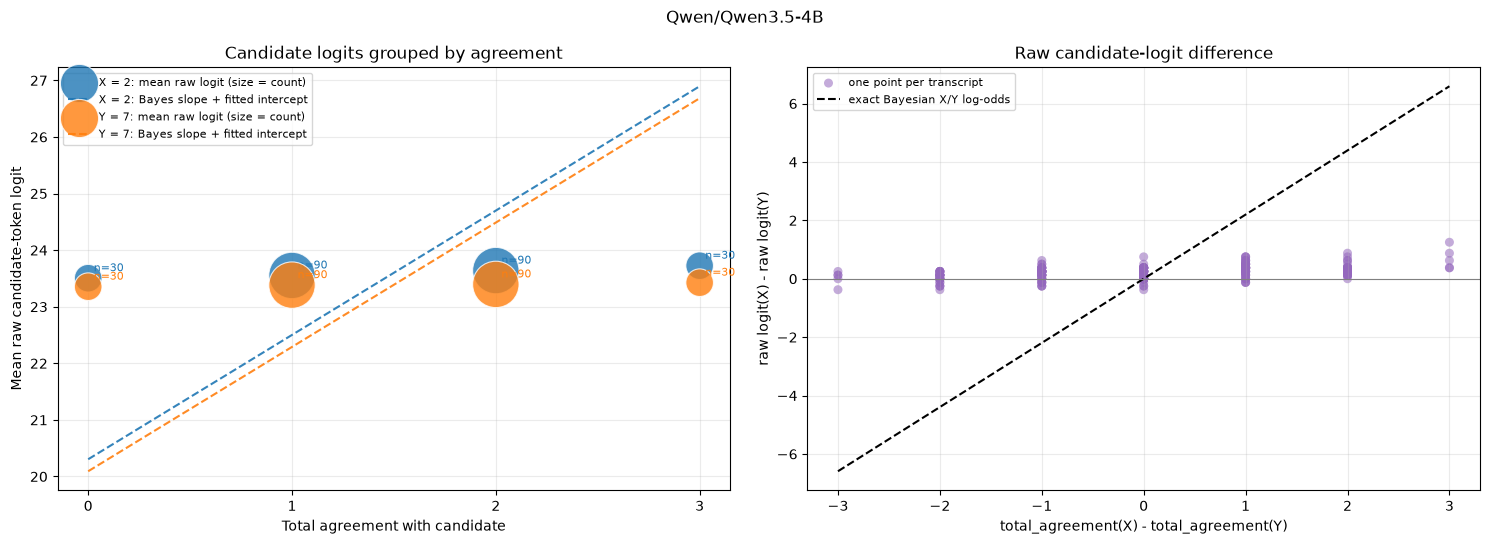

In [18]:
for model_id, rows in results_by_model.items():
    x_groups = grouped_candidate_logits(rows, "x")
    y_groups = grouped_candidate_logits(rows, "y")
    x_intercept = fitted_bayes_intercept(rows, "x")
    y_intercept = fitted_bayes_intercept(rows, "y")

    fig, (ax_agreement, ax_difference) = plt.subplots(1, 2, figsize=(15, 5.5))

    for label, color, groups, intercept in (
        (f"X = {X}", "tab:blue", x_groups, x_intercept),
        (f"Y = {Y}", "tab:orange", y_groups, y_intercept),
    ):
        agreements = [int(group["total_agreement"]) for group in groups]
        means = [float(group["mean_raw_logit"]) for group in groups]
        counts = [int(group["count"]) for group in groups]
        ax_agreement.scatter(
            agreements,
            means,
            s=[35 + 12 * count for count in counts],
            color=color,
            alpha=0.8,
            edgecolor="white",
            linewidth=0.8,
            label=f"{label}: mean raw logit (size = count)",
            zorder=3,
        )
        theory_x = list(range(K + 1))
        theory_y = [bayes_candidate_log_weight(value) + intercept for value in theory_x]
        ax_agreement.plot(
            theory_x,
            theory_y,
            linestyle="--",
            color=color,
            alpha=0.9,
            label=f"{label}: Bayes slope + fitted intercept",
        )
        for agreement, mean, count in zip(agreements, means, counts):
            ax_agreement.annotate(
                f"n={count}",
                (agreement, mean),
                xytext=(4, 5),
                textcoords="offset points",
                fontsize=8,
                color=color,
            )

    ax_agreement.set(
        xlabel="Total agreement with candidate",
        ylabel="Mean raw candidate-token logit",
        title="Candidate logits grouped by agreement",
        xticks=range(K + 1),
    )
    ax_agreement.grid(alpha=0.25)
    ax_agreement.legend(fontsize=8)

    agreement_differences = [
        int(row["total_agreement_x"]) - int(row["total_agreement_y"])
        for row in rows
    ]
    raw_logit_differences = [float(row["x_minus_y_raw_logit"]) for row in rows]
    ax_difference.scatter(
        agreement_differences,
        raw_logit_differences,
        s=42,
        color="tab:purple",
        alpha=0.55,
        edgecolor="none",
        label="one point per transcript",
    )
    difference_grid = list(range(-K, K + 1))
    normative_log_odds = [
        difference * math.log(RELIABILITY / (1 - RELIABILITY))
        for difference in difference_grid
    ]
    ax_difference.plot(
        difference_grid,
        normative_log_odds,
        color="black",
        linestyle="--",
        label="exact Bayesian X/Y log-odds",
    )
    ax_difference.axhline(0, color="grey", linewidth=0.8)
    ax_difference.set(
        xlabel="total_agreement(X) - total_agreement(Y)",
        ylabel="raw logit(X) - raw logit(Y)",
        title="Raw candidate-logit difference",
        xticks=difference_grid,
    )
    ax_difference.grid(alpha=0.25)
    ax_difference.legend(fontsize=8)

    fig.suptitle(model_id)
    fig.tight_layout()
    plt.show()

## Raw wide truth tables

Each table has exactly $2^K$ rows—one per YES/NO answer pattern. For every one-based question-set index $j$ and question index $i$, it includes $a_i^j(X)$ and $a_i^j(Y)$, their totals $a^j(X)$ and $a^j(Y)$, and both raw candidate logits. Multiple configured models receive separate tables because their agreement columns are identical but their logits need not be. The horizontally scrollable display is also written as CSV in the model's experiment directory.

In [19]:
def raw_truth_table(
    rows: list[dict[str, object]],
) -> tuple[list[str], list[list[str]]]:
    by_key = {
        (int(row["answer_pattern_index"]), int(row["question_set_index"])): row
        for row in rows
    }
    headers = ["answer_pattern", *[f"report_i{i}" for i in range(1, K + 1)]]
    for j in range(1, NUM_QUESTION_SETS + 1):
        for i in range(1, K + 1):
            headers.extend([f"agreement_j{j}_i{i}_x", f"agreement_j{j}_i{i}_y"])
        headers.extend([
            f"agreement_j{j}_x",
            f"agreement_j{j}_y",
            f"raw_logit_j{j}_x",
            f"raw_logit_j{j}_y",
            f"raw_logit_j{j}_x_minus_y",
        ])

    matrix = []
    for pattern_index, reports in enumerate(answer_patterns(K)):
        pattern = "".join("Y" if report == "YES" else "N" for report in reports)
        output_row = [pattern, *reports]
        for question_set_index in range(NUM_QUESTION_SETS):
            row = by_key[(pattern_index, question_set_index)]
            x_flags = row["agreement_x_by_question"]
            y_flags = row["agreement_y_by_question"]
            for x_flag, y_flag in zip(x_flags, y_flags):
                output_row.extend([str(int(x_flag)), str(int(y_flag))])
            output_row.extend([
                str(int(row["total_agreement_x"])),
                str(int(row["total_agreement_y"])),
                f"{float(row['x_raw_logit']):.8f}",
                f"{float(row['y_raw_logit']):.8f}",
                f"{float(row['x_minus_y_raw_logit']):.8f}",
            ])
        matrix.append(output_row)
    assert len(matrix) == 2**K
    assert all(len(output_row) == len(headers) for output_row in matrix)
    return headers, matrix


def display_wide_table(headers: list[str], matrix: list[list[str]]) -> None:
    header_html = "".join(f"<th>{html.escape(value)}</th>" for value in headers)
    body_html = "".join(
        "<tr>" + "".join(f"<td>{html.escape(value)}</td>" for value in row) + "</tr>"
        for row in matrix
    )
    display(HTML(
        "<div style='overflow-x:auto; max-width:100%; max-height:650px'>"
        "<table style='border-collapse:collapse; font-size:11px; white-space:nowrap'>"
        "<thead><tr>" + header_html + "</tr></thead><tbody>" + body_html +
        "</tbody></table></div>"
        "<style>th,td{border:1px solid #bbb;padding:3px 6px;text-align:right}"
        "th{position:sticky;top:0;background:#eee;z-index:1}</style>"
    ))


truth_tables_by_model = {}
for model_id, rows in results_by_model.items():
    headers, matrix = raw_truth_table(rows)
    truth_tables_by_model[model_id] = {"headers": headers, "rows": matrix}
    csv_path = EXPERIMENT_ROOT / model_key(model_id) / "agreement_truth_table.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle, lineterminator="\n")
        writer.writerow(headers)
        writer.writerows(matrix)
    print(f"{model_id}: {len(matrix)} x {len(headers)} raw table; saved to {csv_path}")
    display_wide_table(headers, matrix)

Qwen/Qwen3.5-4B: 8 x 334 raw table; saved to /workspace/MATS/artifacts/noisy_channel_bayesian_experiment_1/Qwen_Qwen3.5-4B_227fdbeb/agreement_truth_table.csv


answer_pattern,report_i1,report_i2,report_i3,agreement_j1_i1_x,agreement_j1_i1_y,agreement_j1_i2_x,agreement_j1_i2_y,agreement_j1_i3_x,agreement_j1_i3_y,agreement_j1_x,agreement_j1_y,raw_logit_j1_x,raw_logit_j1_y,raw_logit_j1_x_minus_y,agreement_j2_i1_x,agreement_j2_i1_y,agreement_j2_i2_x,agreement_j2_i2_y,agreement_j2_i3_x,agreement_j2_i3_y,agreement_j2_x,agreement_j2_y,raw_logit_j2_x,raw_logit_j2_y,raw_logit_j2_x_minus_y,agreement_j3_i1_x,agreement_j3_i1_y,agreement_j3_i2_x,agreement_j3_i2_y,agreement_j3_i3_x,agreement_j3_i3_y,agreement_j3_x,agreement_j3_y,raw_logit_j3_x,raw_logit_j3_y,raw_logit_j3_x_minus_y,agreement_j4_i1_x,agreement_j4_i1_y,agreement_j4_i2_x,agreement_j4_i2_y,agreement_j4_i3_x,agreement_j4_i3_y,agreement_j4_x,agreement_j4_y,raw_logit_j4_x,raw_logit_j4_y,raw_logit_j4_x_minus_y,agreement_j5_i1_x,agreement_j5_i1_y,agreement_j5_i2_x,agreement_j5_i2_y,agreement_j5_i3_x,agreement_j5_i3_y,agreement_j5_x,agreement_j5_y,raw_logit_j5_x,raw_logit_j5_y,raw_logit_j5_x_minus_y,agreement_j6_i1_x,agreement_j6_i1_y,agreement_j6_i2_x,agreement_j6_i2_y,agreement_j6_i3_x,agreement_j6_i3_y,agreement_j6_x,agreement_j6_y,raw_logit_j6_x,raw_logit_j6_y,raw_logit_j6_x_minus_y,agreement_j7_i1_x,agreement_j7_i1_y,agreement_j7_i2_x,agreement_j7_i2_y,agreement_j7_i3_x,agreement_j7_i3_y,agreement_j7_x,agreement_j7_y,raw_logit_j7_x,raw_logit_j7_y,raw_logit_j7_x_minus_y,agreement_j8_i1_x,agreement_j8_i1_y,agreement_j8_i2_x,agreement_j8_i2_y,agreement_j8_i3_x,agreement_j8_i3_y,agreement_j8_x,agreement_j8_y,raw_logit_j8_x,raw_logit_j8_y,raw_logit_j8_x_minus_y,agreement_j9_i1_x,agreement_j9_i1_y,agreement_j9_i2_x,agreement_j9_i2_y,agreement_j9_i3_x,agreement_j9_i3_y,agreement_j9_x,agreement_j9_y,raw_logit_j9_x,raw_logit_j9_y,raw_logit_j9_x_minus_y,agreement_j10_i1_x,agreement_j10_i1_y,agreement_j10_i2_x,agreement_j10_i2_y,agreement_j10_i3_x,agreement_j10_i3_y,agreement_j10_x,agreement_j10_y,raw_logit_j10_x,raw_logit_j10_y,raw_logit_j10_x_minus_y,agreement_j11_i1_x,agreement_j11_i1_y,agreement_j11_i2_x,agreement_j11_i2_y,agreement_j11_i3_x,agreement_j11_i3_y,agreement_j11_x,agreement_j11_y,raw_logit_j11_x,raw_logit_j11_y,raw_logit_j11_x_minus_y,agreement_j12_i1_x,agreement_j12_i1_y,agreement_j12_i2_x,agreement_j12_i2_y,agreement_j12_i3_x,agreement_j12_i3_y,agreement_j12_x,agreement_j12_y,raw_logit_j12_x,raw_logit_j12_y,raw_logit_j12_x_minus_y,agreement_j13_i1_x,agreement_j13_i1_y,agreement_j13_i2_x,agreement_j13_i2_y,agreement_j13_i3_x,agreement_j13_i3_y,agreement_j13_x,agreement_j13_y,raw_logit_j13_x,raw_logit_j13_y,raw_logit_j13_x_minus_y,agreement_j14_i1_x,agreement_j14_i1_y,agreement_j14_i2_x,agreement_j14_i2_y,agreement_j14_i3_x,agreement_j14_i3_y,agreement_j14_x,agreement_j14_y,raw_logit_j14_x,raw_logit_j14_y,raw_logit_j14_x_minus_y,agreement_j15_i1_x,agreement_j15_i1_y,agreement_j15_i2_x,agreement_j15_i2_y,agreement_j15_i3_x,agreement_j15_i3_y,agreement_j15_x,agreement_j15_y,raw_logit_j15_x,raw_logit_j15_y,raw_logit_j15_x_minus_y,agreement_j16_i1_x,agreement_j16_i1_y,agreement_j16_i2_x,agreement_j16_i2_y,agreement_j16_i3_x,agreement_j16_i3_y,agreement_j16_x,agreement_j16_y,raw_logit_j16_x,raw_logit_j16_y,raw_logit_j16_x_minus_y,agreement_j17_i1_x,agreement_j17_i1_y,agreement_j17_i2_x,agreement_j17_i2_y,agreement_j17_i3_x,agreement_j17_i3_y,agreement_j17_x,agreement_j17_y,raw_logit_j17_x,raw_logit_j17_y,raw_logit_j17_x_minus_y,agreement_j18_i1_x,agreement_j18_i1_y,agreement_j18_i2_x,agreement_j18_i2_y,agreement_j18_i3_x,agreement_j18_i3_y,agreement_j18_x,agreement_j18_y,raw_logit_j18_x,raw_logit_j18_y,raw_logit_j18_x_minus_y,agreement_j19_i1_x,agreement_j19_i1_y,agreement_j19_i2_x,agreement_j19_i2_y,agreement_j19_i3_x,agreement_j19_i3_y,agreement_j19_x,agreement_j19_y,raw_logit_j19_x,raw_logit_j19_y,raw_logit_j19_x_minus_y,agreement_j20_i1_x,agreement_j20_i1_y,agreement_j20_i2_x,agreement_j20_i2_y,agreement_j20_i3_x,agreement_j20_i3_y,agreement_j20_x,agreement_j20_y,raw_logit_j20_x,raw_logit_j20_y,raw_logit_j20_x_minus_y,agreement_j21_

## Compact audit view

This final long-form sample makes the mapping from question membership and observed report to each agreement bit easy to inspect without scrolling across the full wide table.

In [20]:
for model_id, rows in results_by_model.items():
    sample = rows[0]
    print(model_id)
    for i, (membership, report, x_agrees, y_agrees) in enumerate(zip(
        sample["membership_sets"],
        sample["observed_reports"],
        sample["agreement_x_by_question"],
        sample["agreement_y_by_question"],
    ), start=1):
        print({
            "question_i": i,
            "membership_set": membership,
            "observed_report": report,
            "agreement_i_x": x_agrees,
            "agreement_i_y": y_agrees,
        })
    print({
        "total_agreement_x": sample["total_agreement_x"],
        "total_agreement_y": sample["total_agreement_y"],
        "x_raw_logit": sample["x_raw_logit"],
        "y_raw_logit": sample["y_raw_logit"],
    })

Qwen/Qwen3.5-4B
{'question_i': 1, 'membership_set': [3, 5, 6, 8], 'observed_report': 'YES', 'agreement_i_x': 0, 'agreement_i_y': 0}
{'question_i': 2, 'membership_set': [1, 5, 7, 8], 'observed_report': 'YES', 'agreement_i_x': 0, 'agreement_i_y': 1}
{'question_i': 3, 'membership_set': [1, 4, 5, 6], 'observed_report': 'YES', 'agreement_i_x': 0, 'agreement_i_y': 0}
{'total_agreement_x': 0, 'total_agreement_y': 1, 'x_raw_logit': 23.5, 'y_raw_logit': 23.375}
